# 4 · Interpretability

**What you will do:** find the part of the population that carries the digit, then test whether it is actually necessary.

**What you should take away:** "which neurons?" is the wrong question. The right one is about a *subspace*, and the honest answer to it is a number — the ablation gap — not a list of channels.

> **Required framing, to be stated explicitly in your report:** selection and ablation here establish causal relevance **for the decoder, not for the circuit**. The data are fixed recordings and nothing is intervened upon in the biological system.

Runtime: five to eight minutes (the sparse group lasso is the slow part).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from compbio2026 import data, decoding, plotting, selection

plotting.apply_style()
rng = np.random.default_rng(2026)

shd = data.load("train")
subset = rng.choice(np.flatnonzero(shd.english_mask()), size=1200, replace=False)

# Coarser bins here than in notebook 3: the sparse group lasso solves over
# channels x bins, so 16 bins keeps it to minutes rather than hours.
X, y, t = data.build_design_matrix(shd, bin_ms=50.0, t_max_ms=800.0, smooth_ms=10.0, trials=subset)
K = 50   # how many channels each method may select

print("X", X.shape, " selecting", K, "of", X.shape[1], "channels")

X (1200, 700, 16)  selecting 50 of 700 channels


## The heuristics first

Always run the simple things before the sophisticated ones. If a firing-rate threshold matches the structured method, **that is a result**, not a failure.

In [2]:
selected = {
    "random":           selection.select_random(X.shape[1], K, rng),
    "firing rate":      selection.select_by_rate(X, K),
    "variance":         selection.select_by_variance(X, K),
    "discriminability": selection.select_by_discriminability(X, y, K),
}
for name, ch in selected.items():
    print(f"{name:<18} channels {ch.min():>3}-{ch.max():>3}, median {int(np.median(ch)):>3}")

random             channels   8-698, median 431
firing rate        channels 552-601, median 576
variance           channels 539-591, median 565
discriminability   channels 324-552, median 354


## Sparse group lasso

Each **group** is one cochlear channel across all of its time bins. The group penalty selects channels; within-group sparsity keeps the temporal support tight. The output is a short list of channels — a *candidate basis* for the subspace, not a ranking of neurons.

In [3]:
channels_sgl, group_norms = selection.sparse_group_lasso_channels(
    X, y, group_reg=0.05, l1_reg=0.01, k=K
)
selected["sparse group lasso"] = channels_sgl
print(f"selected {len(channels_sgl)} channels")

selected 50 channels


/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/group_lasso/_fista.py:114: ConvergenceWarning: The FISTA iterations did not converge to a sufficient minimum.
You used subsampling then this is expected, otherwise, try increasing the number of iterations or decreasing the tolerance.
  warnings.warn(


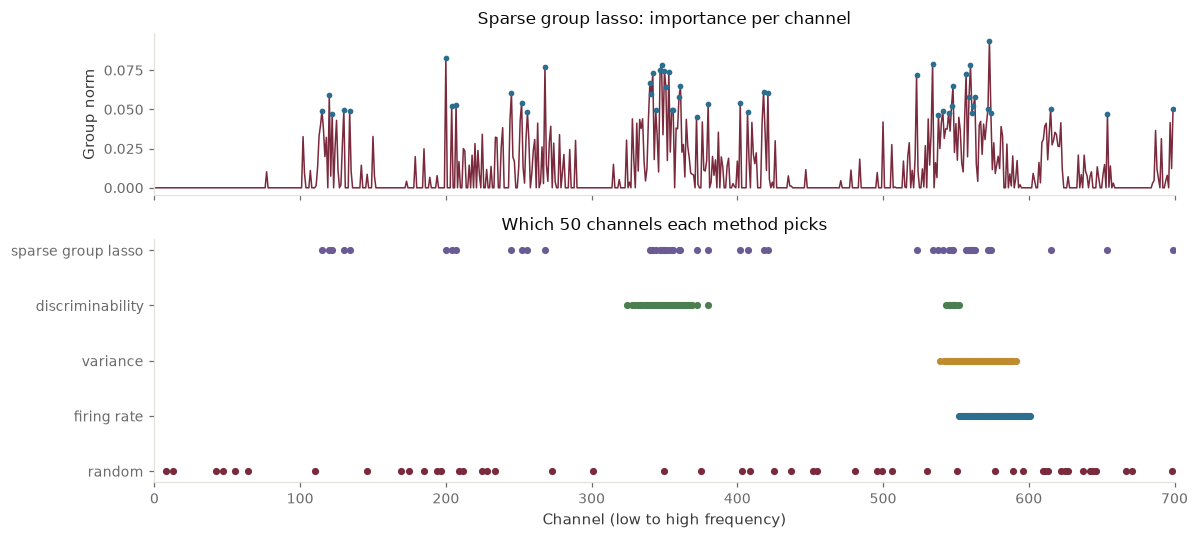

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5), height_ratios=[2, 3], sharex=True)

axes[0].plot(group_norms, color=plotting.ACCENT, lw=1)
axes[0].scatter(channels_sgl, group_norms[channels_sgl], color=plotting.PALETTE[1],
                s=14, zorder=3, linewidths=0)
axes[0].set_ylabel("Group norm")
axes[0].set_title("Sparse group lasso: importance per channel")

for i, (name, ch) in enumerate(selected.items()):
    axes[1].scatter(ch, np.full(len(ch), i), s=22, color=plotting.PALETTE[i], linewidths=0)
axes[1].set_yticks(range(len(selected)))
axes[1].set_yticklabels(list(selected))
axes[1].set_xlabel("Channel (low to high frequency)")
axes[1].set_xlim(0, X.shape[1])
axes[1].set_title(f"Which {K} channels each method picks")
fig.tight_layout()
plotting.savefig(fig, "04_selection", outdir="../plots")

Where the selected channels sit along the tonotopic axis is itself informative: clustering in one frequency band means something different from a spread across the cochlea.

## Ablation — the necessity test

A set the decoder *can* use is not a set it *needs*. Remove the selection, refit from scratch, and measure the drop.

,full,kept,ablated,compensation,chance
random,0.872,0.419,0.868,0.004,0.113
firing rate,0.872,0.253,0.858,0.013,0.113
variance,0.872,0.262,0.857,0.015,0.113
discriminability,0.872,0.292,0.862,0.010,0.113
sparse group lasso,0.872,0.433,0.867,0.005,0.113


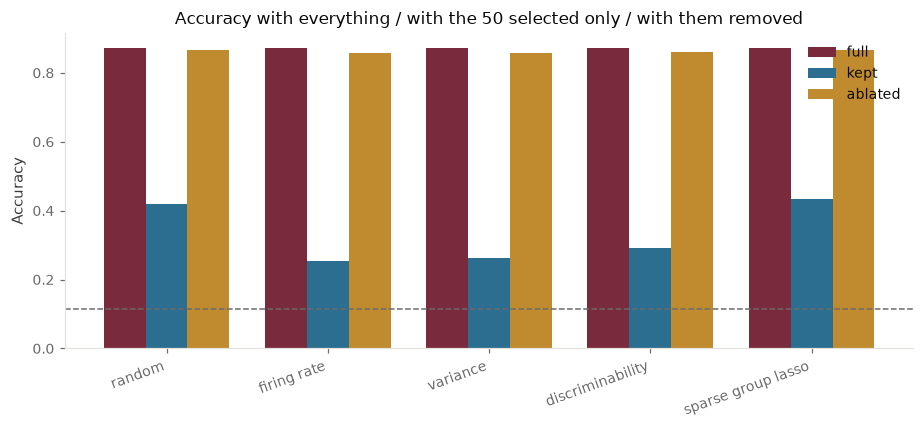

In [5]:
results = {name: selection.ablate(X, y, ch) for name, ch in selected.items()}

fig, ax = plt.subplots(figsize=(8.5, 4))
plotting.ablation_bars(results, ax=ax)
ax.set_title(f"Accuracy with everything / with the {K} selected only / with them removed")
fig.tight_layout()
plotting.savefig(fig, "04_ablation", outdir="../plots")

pd.DataFrame(results).T[["full", "kept", "ablated", "compensation", "chance"]].round(3)

**Read the `compensation` column.** It is full accuracy minus accuracy after removing the selection.

It is near zero for every method. Removing the 50 channels a selector called essential costs the decoder almost nothing, because the remaining 650 carry the same information. That is what notebook 3's channel learning curve predicted.

**Now read the `kept` column, and notice how little the sophisticated method buys.** Sparse group lasso scores barely above *random* channels — and both beat firing rate, variance and discriminability, which pick channels that are individually informative but heavily redundant with each other. A structured method that ties with random selection is telling you something real: in a code this distributed, almost any 50 channels span a similar amount of the relevant subspace.

**None of this is a failed experiment.** It is a quantitative statement about redundancy, and it is the honest answer to "which neurons matter?" — a distributed code does not have a small set of neurons that matter.

## How much of the population do you actually need?

,k,kept,ablated,full,compensation
0,5,0.392,0.873,0.872,-0.002
1,10,0.377,0.872,0.872,0.000
2,25,0.302,0.865,0.872,0.007
3,50,0.292,0.862,0.872,0.010
4,100,0.394,0.854,0.872,0.018
5,200,0.663,0.782,0.872,0.089
6,400,0.817,0.601,0.872,0.271
7,700,0.872,0.113,0.872,0.758


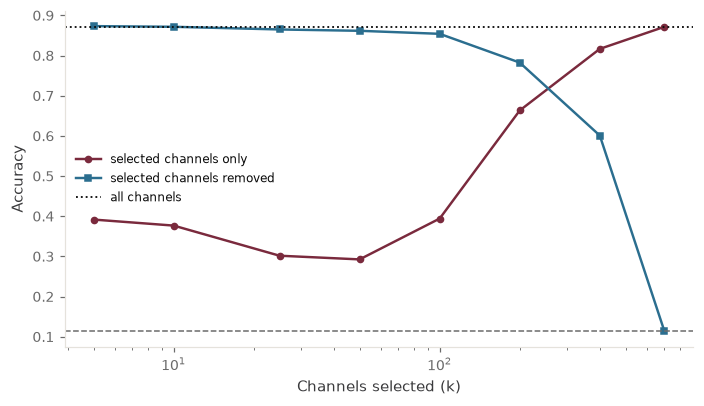

In [6]:
rows = []
for k in [5, 10, 25, 50, 100, 200, 400, 700]:
    ch = selection.select_by_discriminability(X, y, k)
    r = selection.ablate(X, y, ch)
    rows.append({"k": k, **{key: r[key] for key in ("kept", "ablated", "full", "compensation")}})
curve = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(curve["k"], curve["kept"], marker="o", ms=4, color=plotting.ACCENT,
        label="selected channels only")
ax.plot(curve["k"], curve["ablated"], marker="s", ms=4, color=plotting.PALETTE[1],
        label="selected channels removed")
ax.axhline(curve["full"].iloc[0], ls=":", lw=1.2, color=plotting.INK, label="all channels")
ax.axhline(decoding.chance_level(y), ls="--", lw=1, color=plotting.INK_MUTED)
ax.set_xscale("log")
ax.set_xlabel("Channels selected (k)")
ax.set_ylabel("Accuracy")
ax.legend(fontsize=8)
fig.tight_layout()

curve.round(3)

The two curves are the whole story. Accuracy from the selection alone rises quickly and saturates; accuracy after removing the selection barely moves until you remove almost everything. **A subspace of modest dimension carries the digit, and very many different subsets of channels span it.**

## The regularisation path

Do not report one arbitrary operating point. `group_reg` controls how many channels survive; report the trade-off.

In [7]:
path = []
for gr in [0.02, 0.05, 0.10, 0.20]:
    ch, _ = selection.sparse_group_lasso_channels(X, y, group_reg=gr, l1_reg=0.01)
    r = selection.ablate(X, y, ch)
    path.append({"group_reg": gr, "n_selected": len(ch),
                 "kept": r["kept"], "ablated": r["ablated"], "compensation": r["compensation"]})
pd.DataFrame(path).round(3)

/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/group_lasso/_fista.py:114: ConvergenceWarning: The FISTA iterations did not converge to a sufficient minimum.
You used subsampling then this is expected, otherwise, try increasing the number of iterations or decreasing the tolerance.
  warnings.warn(


/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/group_lasso/_fista.py:114: ConvergenceWarning: The FISTA iterations did not converge to a sufficient minimum.
You used subsampling then this is expected, otherwise, try increasing the number of iterations or decreasing the tolerance.
  warnings.warn(


/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/group_lasso/_fista.py:114: ConvergenceWarning: The FISTA iterations did not converge to a sufficient minimum.
You used subsampling then this is expected, otherwise, try increasing the number of iterations or decreasing the tolerance.
  warnings.warn(


/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/group_lasso/_fista.py:114: ConvergenceWarning: The FISTA iterations did not converge to a sufficient minimum.
You used subsampling then this is expected, otherwise, try increasing the number of iterations or decreasing the tolerance.
  warnings.warn(


,group_reg,n_selected,kept,ablated,compensation
0,0.02,424,0.855,0.668,0.203
1,0.05,286,0.822,0.782,0.090
2,0.10,189,0.742,0.835,0.037
3,0.20,114,0.565,0.846,0.026


---

## Exercises

1. **Shared or per-digit?** Run one-vs-rest selection for each digit and compare the selected sets. Do the digits live in overlapping subspaces or orthogonal ones? This is an empirical question with a real answer.
2. **The right control.** Compare selection-only accuracy against *k random* channels, repeated many times. How much of a selector's performance is just "having k channels at all"?
3. **Tonotopic structure.** Are the selected channels clustered in frequency beyond what a shuffled-channel null predicts?
4. **Temporal support.** Sparse group lasso also selects *when* within each channel. Plot the selected time bins — does the decoder rely on onsets, offsets, or the sustained portion?
5. **Write the caveat in your own words.** One paragraph: why does ablation here not license a claim about the biological circuit, and what experiment would?

Next: **[5 · Hair cells](05_hair_cells.ipynb)** — recovering the layer underneath this one.